# Final Project: One Anomaly, Defended

Team members:
- Catalina Cornejo
- Javiera García

GitHub repository:
https://github.com/ccornejod/iele756-region

Video:
- Drive: https://drive.google.com/file/d/1OmixSGVwQQkrC9aRpXaL-ZfFz30uqhHp/view?usp=sharing
- Youtube: https://youtu.be/DJcAoozyrfI

## Project focus

This notebook focuses on one anomaly identified in Tarea 2: the over-representation of foreign patients in obstetric hospitalizations in the GRD data.

The analysis uses pre-computed outputs from the previous tasks rather than re-running the full pipeline. The Census summary provides a demographic baseline for the selected comunas, while the GRD summary provides the overall hospitalization baseline. The goal is to isolate the anomaly, compare it against these baselines, and evaluate possible alternative explanations.

## Anomaly statement

Our anomaly is the over-representation of foreign patients in obstetric hospitalizations in the GRD data. Across Renca, Lo Barnechea, and Buin, foreign patients represent only a small share of the overall population and of all GRD hospital discharges. However, within ICD-10 Chapter 15, which corresponds to pregnancy, childbirth, and the puerperium, their share is substantially higher.

This is surprising because we would have expected the foreign-patient share in obstetric hospitalizations to be closer to their overall share in GRD discharges, or at least closer to their demographic weight in the selected comunas. Instead, Chapter 15 stands out as a specific diagnostic category where foreign patients are clearly over-represented.

## 1. Load pre-computed outputs

This notebook starts by loading the CSV outputs generated in previous tasks. These files provide the demographic and overall hospitalization baselines needed to frame the anomaly.

The files used in this section are:

- `census_team20.csv`: demographic summary for the assigned comunas.
- `grd_team20.csv`: overall GRD summary for the assigned comunas.

These files allow us to compute two baseline values: the foreign-born share in the population and the foreign-patient share in all GRD hospital discharges. Later, a small additional chapter-by-nationality table is created only for the specific anomaly, because that aggregation was not required as an output in previous tasks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

census = pd.read_csv("./census_team20.csv")
grd_summary = pd.read_csv("./grd_team20.csv")

display(census)
display(grd_summary)

,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13115,Lo Barnechea,112620,98589,12198,10.831113,34.0,42.0,14.868803,15.031679,63.152090,73.112093,45.969697
1,13128,Renca,143622,130218,12523,8.719416,35.0,33.0,10.895060,12.027874,61.276611,72.134725,47.257795
2,13402,Buin,116969,110229,5960,5.095367,34.0,34.0,12.185436,13.374942,63.132818,72.907216,46.352114


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13402,Buin,15457,14669,788,5.10,5.576291,5.603302,5.086142,1.488646,2.956589,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,1321.461242
1,13115,Lo Barnechea,6883,6204,679,9.86,5.166742,5.239609,4.483568,1.425977,1.772483,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",611.170307
2,13128,Renca,25748,24002,1746,6.78,6.392185,6.495590,4.999133,1.464696,3.068199,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",1792.761555


## 2. Baseline comparison

Before focusing on Chapter 15, we first compute the baseline foreign share in the selected comunas.

The first baseline comes from the Census summary. It is calculated as the total foreign-born population divided by the total population across Renca, Lo Barnechea, and Buin.

The second baseline comes from the GRD summary. It is calculated as the total number of foreign patients divided by all GRD hospital discharges in the same comunas.

These two measures are not identical: Census uses place of birth, while GRD uses nationality. Even so, they provide two useful reference points for evaluating whether Chapter 15 differs from the general demographic and hospitalization composition.

In [2]:
# Population baseline
total_population = census["pop_total"].sum()
total_foreign_population = census["pop_foreign"].sum()
population_foreign_share = total_foreign_population / total_population * 100

# GRD baseline
total_grd = grd_summary["grd_total"].sum()
total_foreign_grd = grd_summary["grd_foreign"].sum()
grd_foreign_share = total_foreign_grd / total_grd * 100

baseline_summary = pd.DataFrame({
    "Baseline": [
        "Foreign-born share in total population",
        "Foreign-patient share in all GRD discharges"
    ],
    "Foreign share (%)": [
        population_foreign_share,
        grd_foreign_share
    ]
})

baseline_summary["Foreign share (%)"] = baseline_summary["Foreign share (%)"].round(2)

display(baseline_summary)

,Baseline,Foreign share (%)
0,Foreign-born share in total population,8.22
1,Foreign-patient share in all GRD discharges,6.68


The baseline comparison shows that foreign-born residents represent 8.22% of the total population across the three selected comunas. In the GRD data, foreign patients represent 6.68% of all hospital discharges.

These values establish the expected reference range for the anomaly. If obstetric hospitalizations followed the same general composition as the population or the overall GRD discharge profile, the foreign share in Chapter 15 would be expected to be closer to this range. Therefore, if Chapter 15 shows a value close to 20%, it would represent a clear deviation from both baselines.

## 3. Create the chapter-by-nationality table

The comuna-level GRD summary from Tarea 2 provides the overall hospitalization baseline, but it does not include discharge counts by ICD-10 chapter and nationality group. Since the selected anomaly specifically concerns Chapter 15, we need one additional aggregation that was not required in the previous assignments.

This step does not reproduce the full Tarea 2 analysis. Instead, it loads only the minimum GRD variables needed for the anomaly: comuna, nationality, and main diagnosis code. The data is then filtered to the assigned comunas, linked to the ICD-10 lookup table, and aggregated by diagnostic chapter and nationality group.

The resulting table is saved as `chapter_nat_summary.csv` so the anomaly can be reproduced directly from a small intermediate output.

In [3]:
import zipfile
# ------------------------------------------------------------
# Step 1: Define the minimum columns needed for the anomaly
# ------------------------------------------------------------

grd_cols_min = [
    "COMUNA",
    "NACIONALIDAD",
    "DIAGNOSTICO1"
]

# ------------------------------------------------------------
# Step 2: Function to load one GRD file safely
# ------------------------------------------------------------

def load_grd_minimal(zip_path, txt_name, year):
    """
    Loads only the minimum GRD columns needed for the final anomaly.
    This avoids re-running the full Tarea 2 pipeline.
    """
    with zipfile.ZipFile(zip_path) as z:
        with z.open(txt_name) as f:
            try:
                df = pd.read_csv(
                    f,
                    sep="|",
                    encoding="utf-16",
                    usecols=grd_cols_min,
                    low_memory=False
                )
                print(f"{year}: loaded with utf-16")
            except Exception:
                f.seek(0)
                df = pd.read_csv(
                    f,
                    sep="|",
                    encoding="latin-1",
                    usecols=grd_cols_min,
                    low_memory=False
                )
                print(f"{year}: loaded with latin-1")
    
    df["year"] = year
    return df

# ------------------------------------------------------------
# Step 3: Load GRD 2022, 2023, and 2024
# ------------------------------------------------------------

grd_2022 = load_grd_minimal(
    "GRD_PUBLICO_2022.zip",
    "GRD_PUBLICO_EXTERNO_2022.txt",
    2022
)

grd_2023 = load_grd_minimal(
    "GRD_PUBLICO_2023.zip",
    "GRD_PUBLICO_2023.txt",
    2023
)

grd_2024 = load_grd_minimal(
    "GRD_PUBLICO_2024.zip",
    "GRD_PUBLICO_2024.txt",
    2024
)

grd_min = pd.concat([grd_2022, grd_2023, grd_2024], ignore_index=True)

print("Total GRD rows loaded:", len(grd_min))

# ------------------------------------------------------------
# Step 4: Filter to the assigned comunas
# ------------------------------------------------------------

my_comunas = ["RENCA", "LO BARNECHEA", "BUIN"]

grd_min["COMUNA_clean"] = (
    grd_min["COMUNA"]
    .astype(str)
    .str.upper()
    .str.strip()
)

grd_com = grd_min[grd_min["COMUNA_clean"].isin(my_comunas)].copy()

print("Rows in assigned comunas:", len(grd_com))
display(grd_com["COMUNA_clean"].value_counts())

# ------------------------------------------------------------
# Step 5: Create nationality group
# ------------------------------------------------------------

grd_com["NACIONALIDAD_clean"] = (
    grd_com["NACIONALIDAD"]
    .astype(str)
    .str.upper()
    .str.strip()
)

grd_com["nat_group"] = np.where(
    grd_com["NACIONALIDAD_clean"] == "CHILE",
    "Chilean",
    "Foreign"
)

display(grd_com["nat_group"].value_counts())

# ------------------------------------------------------------
# Step 6: Load ICD-10 lookup and merge diagnostic chapter
# ------------------------------------------------------------

cie10 = pd.read_excel("CIE-10.xlsx", sheet_name="CIE 10")

cie10_lookup = (
    cie10[["Código", "Descripción", "Capítulo"]]
    .drop_duplicates(subset="Código")
    .copy()
)

grd_com["DIAGNOSTICO1_clean"] = (
    grd_com["DIAGNOSTICO1"]
    .astype(str)
    .str.upper()
    .str.strip()
)

cie10_lookup["Codigo_clean"] = (
    cie10_lookup["Código"]
    .astype(str)
    .str.upper()
    .str.strip()
)

grd_com = grd_com.merge(
    cie10_lookup[["Codigo_clean", "Descripción", "Capítulo"]],
    left_on="DIAGNOSTICO1_clean",
    right_on="Codigo_clean",
    how="left"
)

print("Rows without ICD-10 chapter match:", grd_com["Capítulo"].isna().sum())

# ------------------------------------------------------------
# Step 7: Create chapter-by-nationality summary
# ------------------------------------------------------------

chapter_nat_summary = (
    grd_com
    .dropna(subset=["Capítulo"])
    .groupby(["Capítulo", "nat_group"])
    .size()
    .reset_index(name="count")
)

chapter_nat_summary["chapter_total"] = (
    chapter_nat_summary
    .groupby("Capítulo")["count"]
    .transform("sum")
)

chapter_nat_summary["share_within_chapter"] = (
    chapter_nat_summary["count"] / chapter_nat_summary["chapter_total"] * 100
)

chapter_nat_summary = chapter_nat_summary.sort_values(
    ["chapter_total", "Capítulo", "nat_group"],
    ascending=[False, True, True]
).reset_index(drop=True)

display(chapter_nat_summary.head(20))

# ------------------------------------------------------------
# Step 8: Save small output
# ------------------------------------------------------------

chapter_nat_summary.to_csv("chapter_nat_summary.csv", index=False)

print("Saved file: chapter_nat_summary.csv")

2022: loaded with utf-16
2023: loaded with utf-16
2024: loaded with latin-1
Total GRD rows loaded: 3058240
Rows in assigned comunas: 48088


COMUNA_clean
RENCA           25748
BUIN            15457
LO BARNECHEA     6883
Name: count, dtype: int64

nat_group
Chilean    44875
Foreign     3213
Name: count, dtype: int64

Rows without ICD-10 chapter match: 4


,Capítulo,nat_group,count,chapter_total,share_within_chapter
0,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",Chilean,6185,7701,80.314245
1,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",Foreign,1516,7701,19.685755
2,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,Chilean,6503,6847,94.975902
3,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,Foreign,344,6847,5.024098
4,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",Chilean,4689,4946,94.803882
5,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",Foreign,257,4946,5.196118
6,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,Chilean,4442,4550,97.626374
7,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,Foreign,108,4550,2.373626
8,Cap.14 ENFERMEDADES DEL APARATO GENITOURINARI...,Chilean,3994,4259,93.777882
9,Cap.14 ENFERMEDADES DEL APARATO GENITOURINARI...,Foreign,265,4259,6.222118


Saved file: chapter_nat_summary.csv


In [4]:
chapter_nat = pd.read_csv("./chapter_nat_summary.csv")

display(chapter_nat.head())

,Capítulo,nat_group,count,chapter_total,share_within_chapter
0,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",Chilean,6185,7701,80.314245
1,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",Foreign,1516,7701,19.685755
2,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,Chilean,6503,6847,94.975902
3,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,Foreign,344,6847,5.024098
4,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",Chilean,4689,4946,94.803882


The auxiliary chapter-by-nationality table was successfully created from the minimum GRD variables needed for this anomaly. The filtered dataset contains 48,088 discharges across Renca, Lo Barnechea, and Buin, matching the total number of GRD discharges reported in Tarea 2.

The nationality distribution also matches the previous GRD summary: 44,875 Chilean patients and 3,213 foreign patients. Only 4 rows failed to match an ICD-10 chapter, which is negligible relative to the size of the filtered dataset.

The table shows that Chapter 15 contains 7,701 discharges, of which 1,516 correspond to foreign patients. This gives a foreign-patient share of 19.69%, making Chapter 15 the clearest diagnostic category where foreign patients are over-represented.

## 4. Isolating the anomaly: Chapter 15

The selected anomaly specifically concerns ICD-10 Chapter 15, which corresponds to pregnancy, childbirth, and the puerperium.

Using the chapter-by-nationality table created above, we isolate Chapter 15 and compute the foreign-patient share within that diagnostic category. This is the main number behind the anomaly.

In [5]:
chapter15 = chapter_nat_summary[
    chapter_nat_summary["Capítulo"].str.contains("EMBARAZO", case=False, na=False)
].copy()

display(chapter15)

chapter15_total = chapter15["count"].sum()

chapter15_foreign = chapter15.loc[
    chapter15["nat_group"] == "Foreign",
    "count"
].sum()

chapter15_foreign_share = chapter15_foreign / chapter15_total * 100

print(f"Chapter 15 total discharges: {chapter15_total:,}")
print(f"Chapter 15 foreign discharges: {chapter15_foreign:,}")
print(f"Chapter 15 foreign-patient share: {chapter15_foreign_share:.2f}%")

,Capítulo,nat_group,count,chapter_total,share_within_chapter
0,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",Chilean,6185,7701,80.314245
1,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",Foreign,1516,7701,19.685755


Chapter 15 total discharges: 7,701
Chapter 15 foreign discharges: 1,516
Chapter 15 foreign-patient share: 19.69%


Chapter 15 contains 7,701 hospital discharges across Renca, Lo Barnechea, and Buin. Of these, 6,185 correspond to Chilean patients and 1,516 correspond to foreign patients. This means that the foreign-patient share in obstetric hospitalizations reaches 19.69%.

This value is substantially higher than both baselines computed earlier: 8.22% for the foreign-born population share and 6.68% for the foreign-patient share in all GRD discharges. In other words, the foreign-patient share in Chapter 15 is not aligned with either their general demographic weight or their overall hospitalization weight. Instead, their share in obstetric hospitalizations is almost three times the overall GRD baseline.

This confirms the anomaly: ICD-10 Chapter 15 stands out as a diagnostic category where foreign patients are clearly over-represented compared with what we would have expected from the broader population and hospitalization patterns.

## 5. Headline figure

The headline figure compares the foreign share in three reference points: the Census population baseline, the overall GRD hospitalization baseline, and ICD-10 Chapter 15.

If Chapter 15 followed the same composition as the population or the overall GRD discharge profile, its foreign-patient share would be expected to be close to the first two values. Instead, it is substantially higher.

In [16]:
headline_df = pd.DataFrame({
    "Reference": [
        "Census population\nforeign-born share",
        "All GRD discharges\nforeign-patient share",
        "Chapter 15\nforeign-patient share"
    ],
    "Foreign share (%)": [
        population_foreign_share,
        grd_foreign_share,
        chapter15_foreign_share
    ]
})

headline_df["Foreign share (%)"] = headline_df["Foreign share (%)"].round(2)

display(headline_df)

,Reference,Foreign share (%)
0,Census population\nforeign-born share,8.22
1,All GRD discharges\nforeign-patient share,6.68
2,Chapter 15\nforeign-patient share,19.69


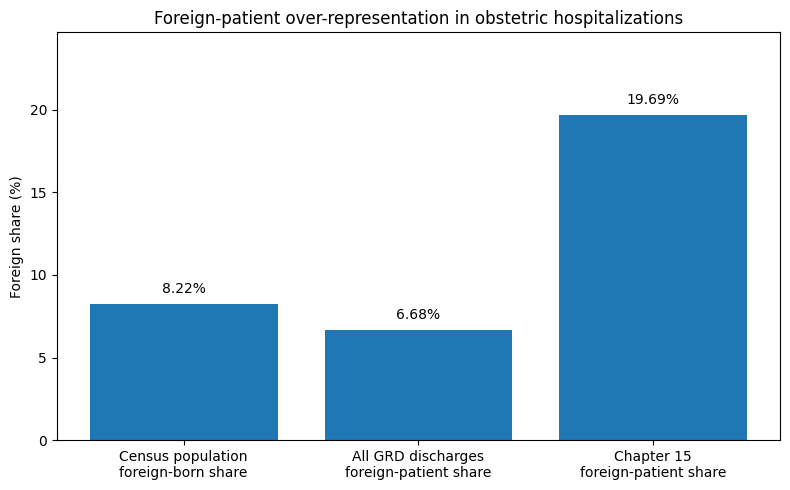

In [7]:
os.makedirs("figs", exist_ok=True)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    headline_df["Reference"],
    headline_df["Foreign share (%)"]
)

plt.ylabel("Foreign share (%)")
plt.title("Foreign-patient over-representation in obstetric hospitalizations")
plt.ylim(0, max(headline_df["Foreign share (%)"]) + 5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("figs/headline.png", dpi=300, bbox_inches="tight")
plt.show()

The headline figure shows the anomaly clearly. Foreign-born residents represent 8.22% of the total population across Renca, Lo Barnechea, and Buin, and foreign patients represent 6.68% of all GRD discharges. However, within ICD-10 Chapter 15, the foreign-patient share rises to 19.69%.

This means that obstetric hospitalizations do not follow the same composition as either the population baseline or the overall hospitalization baseline. Chapter 15 therefore shows a clear and substantial deviation from what we would have expected based on those two reference points.


## 6. Alternative explanation check 1: Is the anomaly driven by only one comuna?

One possible explanation is that the high foreign-patient share in Chapter 15 is not a general pattern across the selected comunas, but instead is driven by only one comuna.

To evaluate this, we compute the Chapter 15 foreign-patient share separately for Renca, Lo Barnechea, and Buin.

In [8]:
chapter15_comuna = grd_com[
    grd_com["Capítulo"].str.contains("EMBARAZO", case=False, na=False)
].copy()

chapter15_comuna_summary = (
    chapter15_comuna
    .groupby(["COMUNA_clean", "nat_group"])
    .size()
    .reset_index(name="count")
)

chapter15_comuna_pivot = (
    chapter15_comuna_summary
    .pivot(index="COMUNA_clean", columns="nat_group", values="count")
    .fillna(0)
    .reset_index()
)

chapter15_comuna_pivot["chapter15_total"] = (
    chapter15_comuna_pivot["Chilean"] + chapter15_comuna_pivot["Foreign"]
)

chapter15_comuna_pivot["chapter15_foreign_share"] = (
    chapter15_comuna_pivot["Foreign"] / chapter15_comuna_pivot["chapter15_total"] * 100
)

chapter15_comuna_pivot = chapter15_comuna_pivot.sort_values(
    "chapter15_foreign_share",
    ascending=False
)

display(chapter15_comuna_pivot)

nat_group,COMUNA_clean,Chilean,Foreign,chapter15_total,chapter15_foreign_share
1,LO BARNECHEA,804,238,1042,22.840691
2,RENCA,3381,885,4266,20.745429
0,BUIN,2000,393,2393,16.422900


The comuna-level check shows that the over-representation of foreign patients in Chapter 15 is not driven by only one comuna. The foreign-patient share in obstetric hospitalizations is high in all three selected comunas: 22.84% in Lo Barnechea, 20.75% in Renca, and 16.42% in Buin.

Although the magnitude varies, all three values are well above the overall GRD baseline of 6.68%. This suggests that the anomaly is not driven by a single comuna, but appears consistently across Renca, Lo Barnechea, and Buin.

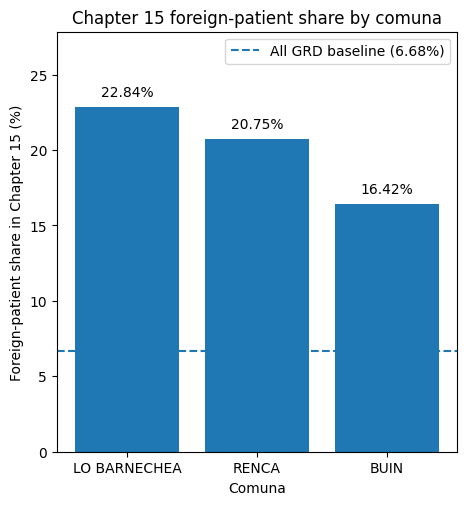

In [17]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    chapter15_comuna_pivot["COMUNA_clean"],
    chapter15_comuna_pivot["chapter15_foreign_share"]
)

plt.axhline(
    grd_foreign_share,
    linestyle="--",
    label=f"All GRD baseline ({grd_foreign_share:.2f}%)"
)

plt.ylabel("Foreign-patient share in Chapter 15 (%)")
plt.xlabel("Comuna")
plt.title("Chapter 15 foreign-patient share by comuna")
plt.ylim(0, max(chapter15_comuna_pivot["chapter15_foreign_share"]) + 5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.legend()
plt.subplots_adjust(left=0.45, right=0.95, top=0.92, bottom=0.08)
plt.savefig("figs/check1_chapter15_by_comuna.png", dpi=300, bbox_inches="tight")
plt.show()

The comuna-level figure reinforces the anomaly rather than contradicting it. The foreign-patient share in Chapter 15 is above the overall GRD baseline in all three comunas: 22.84% in Lo Barnechea, 20.75% in Renca, and 16.42% in Buin, compared with a baseline of 6.68% across all GRD discharges.

This means that the combined Chapter 15 result is not being driven by a single comuna. The magnitude of the anomaly varies across places, but the pattern is consistent: obstetric hospitalizations show a substantially higher foreign-patient share than the general hospitalization profile in each comuna.

## 7. Alternative explanation check 2: Is Chapter 15 unique?

A second possible explanation is that foreign patients are generally over-represented across all diagnostic chapters, not specifically in obstetric hospitalizations.

To evaluate this, we compare the foreign-patient share across the main ICD-10 chapters. If the anomaly were simply part of a general pattern, several chapters would show foreign-patient shares close to Chapter 15. If Chapter 15 stands out clearly, then the anomaly is more specific to pregnancy, childbirth, and puerperium hospitalizations.

In [10]:
# Compare foreign-patient share across diagnostic chapters

chapter_foreign_share = (
    chapter_nat_summary
    .pivot(index="Capítulo", columns="nat_group", values="count")
    .fillna(0)
    .reset_index()
)

chapter_foreign_share["chapter_total"] = (
    chapter_foreign_share["Chilean"] + chapter_foreign_share["Foreign"]
)

chapter_foreign_share["foreign_share"] = (
    chapter_foreign_share["Foreign"] / chapter_foreign_share["chapter_total"] * 100
)

# Keep chapters with a reasonable number of discharges to avoid tiny denominators
chapter_foreign_share_filtered = chapter_foreign_share[
    chapter_foreign_share["chapter_total"] >= 100
].copy()

# Create shorter labels for readability
chapter_foreign_share_filtered["chapter_short"] = (
    chapter_foreign_share_filtered["Capítulo"]
    .str.replace(r"Cap\.\d+\s*", "", regex=True)
    .str.split("(").str[0]
    .str.strip()
)

chapter_foreign_share_filtered = chapter_foreign_share_filtered.sort_values(
    "foreign_share",
    ascending=False
)

display(
    chapter_foreign_share_filtered[
        ["chapter_short", "Chilean", "Foreign", "chapter_total", "foreign_share"]
    ].round(2)
)

nat_group,chapter_short,Chilean,Foreign,chapter_total,foreign_share
14,"EMBARAZO, PARTO Y PUERPERIO",6185.0,1516.0,7701.0,19.69
1,NEOPLASIAS,3136.0,250.0,3386.0,7.38
13,ENFERMEDADES DEL APARATO GENITOURINARIO,3994.0,265.0,4259.0,6.22
2,ENFERMEDADES DE LA SANGRE Y ÓRGANOS HEMATOPOYÉ...,235.0,14.0,249.0,5.62
19,FACTORES QUE INFLUYEN EN EL ESTADO DE SALUD Y ...,1230.0,71.0,1301.0,5.46
18,"LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS ...",4689.0,257.0,4946.0,5.20
10,ENFERMEDADES DEL APARATO DIGESTIVO,6503.0,344.0,6847.0,5.02
11,ENFERMEDADES DE LA PIEL Y DEL TEJIDO SUBCUTÁNEO,561.0,25.0,586.0,4.27
16,"MALFORMACIONES CONGÉNITAS, DEFORMIDADES Y ANOM...",547.0,23.0,570.0,4.04
0,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,811.0,33.0,844.0,3.91


The comparison across ICD-10 chapters shows that Chapter 15 is not simply part of a general pattern of foreign-patient over-representation. It is the clear outlier.

Chapter 15 has a foreign-patient share of 19.69%, while the next highest chapter, neoplasms, reaches only 7.38%. Most other diagnostic chapters are close to or below the overall GRD baseline of 6.68%. For example, genitourinary diseases reach 6.22%, injuries reach 5.20%, digestive diseases reach 5.02%, respiratory diseases reach 2.37%, and circulatory diseases reach 2.23%.

This suggests that the anomaly is concentrated in pregnancy, childbirth, and puerperium hospitalizations. Foreign patients are not uniformly over-represented across the GRD data; their over-representation is concentrated in Chapter 15.

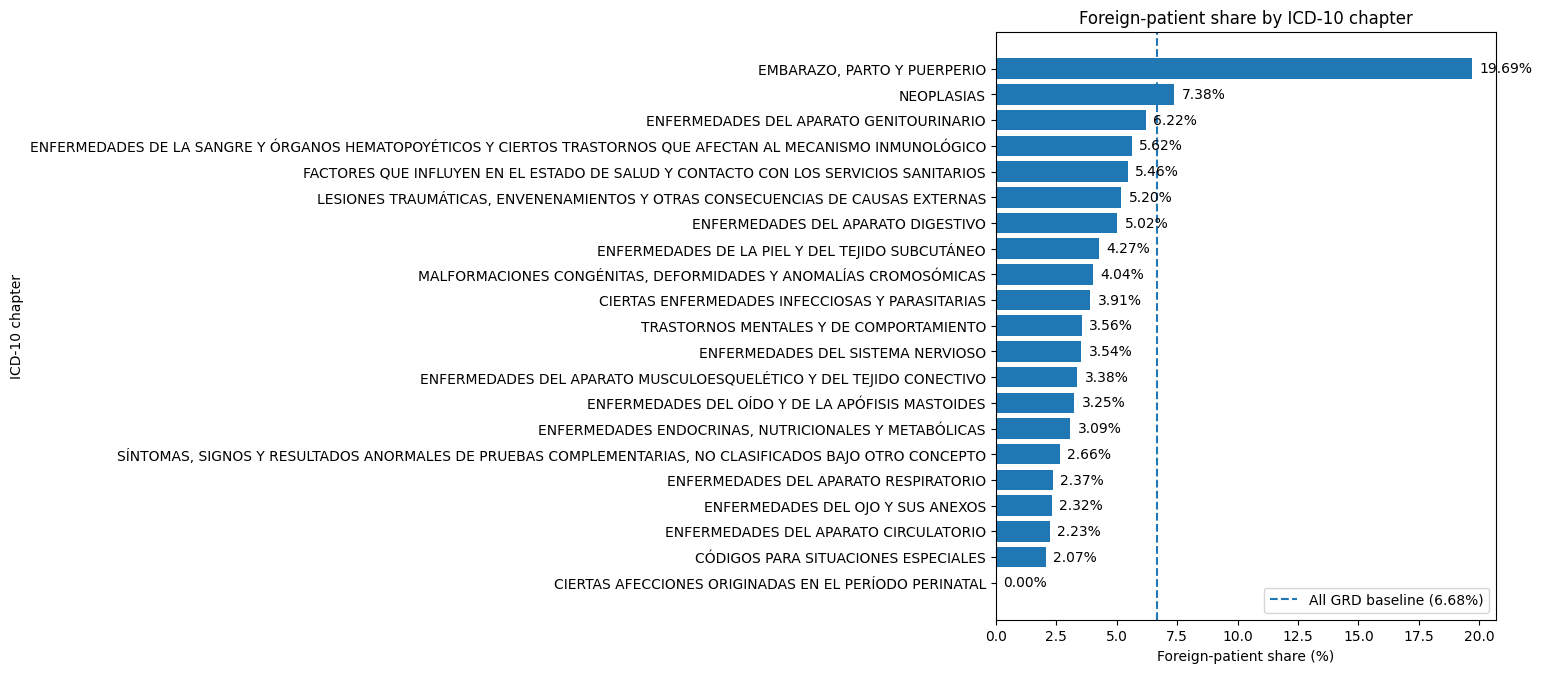

In [18]:
# Plot top diagnostic chapters by foreign-patient share

plot_chapters = chapter_foreign_share_filtered.copy()

plt.figure(figsize=(10, 7))

bars = plt.barh(
    plot_chapters["chapter_short"],
    plot_chapters["foreign_share"]
)

plt.axvline(
    grd_foreign_share,
    linestyle="--",
    label=f"All GRD baseline ({grd_foreign_share:.2f}%)"
)

plt.xlabel("Foreign-patient share (%)")
plt.ylabel("ICD-10 chapter")
plt.title("Foreign-patient share by ICD-10 chapter")
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center"
    )

plt.legend()
plt.subplots_adjust(left=0.45, right=0.95, top=0.92, bottom=0.08)
plt.savefig("figs/check2_foreign_share_by_chapter.png", dpi=300, bbox_inches="tight")
plt.show()

The chapter-level figure confirms that Chapter 15 is the clear outlier. The foreign-patient share in pregnancy and childbirth hospitalizations reaches 19.69%, while the next highest chapter, neoplasms, reaches only 7.38%.

Most other diagnostic chapters are close to or below the overall GRD baseline of 6.68%. This shows that the anomaly is not explained by a general over-representation of foreign patients across the GRD dataset. Instead, the pattern is concentrated in Chapter 15, which makes the anomaly specific to obstetric hospitalizations.

## 8. Alternative explanation check 3: Is Chapter 15 just reflecting the local foreign population share?

A third possible explanation is that Chapter 15 has a higher foreign-patient share simply because the selected comunas have a higher foreign-born population share.

To evaluate this, we compare the Chapter 15 foreign-patient share with two comuna-level baselines: the foreign-born share in the Census population and the foreign-patient share across all GRD discharges. If Chapter 15 only reflected the local demographic composition, its values should be close to the Census baseline in each comuna.

In [14]:
# Compare Chapter 15 share against comuna-level population and GRD baselines

# Keep relevant Census baseline
census_baseline_comuna = census[
    ["codigo_comuna", "nombre_comuna", "pct_foreign"]
].copy()

census_baseline_comuna = census_baseline_comuna.rename(
    columns={"pct_foreign": "census_foreign_share"}
)

# Keep relevant GRD baseline
grd_baseline_comuna = grd_summary[
    ["codigo_comuna", "nombre_comuna", "grd_pct_foreign"]
].copy()

grd_baseline_comuna = grd_baseline_comuna.rename(
    columns={"grd_pct_foreign": "all_grd_foreign_share"}
)

# Prepare Chapter 15 by comuna table
chapter15_by_comuna = chapter15_comuna_pivot.copy()

comuna_name_map = {
    "LO BARNECHEA": "Lo Barnechea",
    "RENCA": "Renca",
    "BUIN": "Buin"
}

chapter15_by_comuna["nombre_comuna"] = (
    chapter15_by_comuna["COMUNA_clean"].map(comuna_name_map)
)

chapter15_by_comuna = chapter15_by_comuna[
    ["nombre_comuna", "chapter15_foreign_share"]
].copy()

# Merge all baselines
check3 = (
    census_baseline_comuna
    .merge(grd_baseline_comuna[["nombre_comuna", "all_grd_foreign_share"]],
           on="nombre_comuna",
           how="left")
    .merge(chapter15_by_comuna,
           on="nombre_comuna",
           how="left")
)

# Difference between Chapter 15 and baselines
check3["gap_vs_census"] = (
    check3["chapter15_foreign_share"] - check3["census_foreign_share"]
)

check3["gap_vs_all_grd"] = (
    check3["chapter15_foreign_share"] - check3["all_grd_foreign_share"]
)

check3 = check3.sort_values("chapter15_foreign_share", ascending=False)

display(check3.round(2))

,codigo_comuna,nombre_comuna,census_foreign_share,all_grd_foreign_share,chapter15_foreign_share,gap_vs_census,gap_vs_all_grd
0,13115,Lo Barnechea,10.83,9.86,22.84,12.01,12.98
1,13128,Renca,8.72,6.78,20.75,12.03,13.97
2,13402,Buin,5.10,5.10,16.42,11.33,11.32


This comparison shows that the Chapter 15 anomaly is not explained only by the local foreign-born population share. In all three comunas, the foreign-patient share in Chapter 15 is much higher than both the Census foreign-born baseline and the overall GRD foreign-patient baseline.

In Lo Barnechea, foreign-born residents represent 10.83% of the population and foreign patients represent 9.86% of all GRD discharges, but they account for 22.84% of Chapter 15 discharges. In Renca, the pattern is similar: the Census baseline is 8.72%, the overall GRD baseline is 6.78%, and the Chapter 15 share rises to 20.75%. In Buin, both baselines are 5.10%, while the Chapter 15 share reaches 16.42%.

The gap is also very consistent across comunas. Chapter 15 is between 11 and 14 percentage points above the local baselines in all three places. This suggests that the anomaly is not simply a reflection of having more foreign-born residents in one comuna; it is a specific over-representation within obstetric hospitalizations.

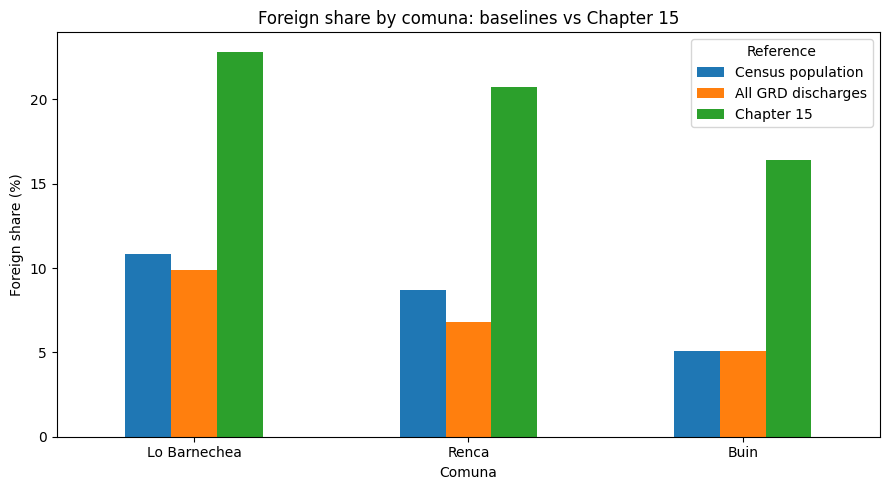

In [15]:
# Plot comuna-level comparison between baselines and Chapter 15

check3_plot = check3[
    [
        "nombre_comuna",
        "census_foreign_share",
        "all_grd_foreign_share",
        "chapter15_foreign_share"
    ]
].copy()

check3_plot = check3_plot.rename(columns={
    "census_foreign_share": "Census population",
    "all_grd_foreign_share": "All GRD discharges",
    "chapter15_foreign_share": "Chapter 15"
})

check3_plot = check3_plot.set_index("nombre_comuna")

ax = check3_plot.plot(kind="bar", figsize=(9, 5))

plt.ylabel("Foreign share (%)")
plt.xlabel("Comuna")
plt.title("Foreign share by comuna: baselines vs Chapter 15")
plt.xticks(rotation=0)
plt.legend(title="Reference")
plt.tight_layout()
plt.savefig("figs/check3_baselines_by_comuna.png", dpi=300, bbox_inches="tight")
plt.show()



The comuna-level comparison shows the same pattern in all three places. In each comuna, the Chapter 15 foreign-patient share is substantially higher than both the Census population baseline and the overall GRD hospitalization baseline.

This is important because it weakens a simple demographic explanation. If Chapter 15 only reflected the local foreign-born population share, the green bars would be close to the blue bars. Instead, the Chapter 15 share is consistently much higher: 22.84% in Lo Barnechea, 20.75% in Renca, and 16.42% in Buin.

Therefore, the anomaly is not only visible in the pooled data. It remains visible when each comuna is compared against its own local baselines.

## 9. Interpretation and limitations

The anomaly is clear in the descriptive evidence: foreign patients represent 6.68% of all GRD discharges across Renca, Lo Barnechea, and Buin, but they represent 19.69% of discharges in ICD-10 Chapter 15. This means that the foreign-patient share in obstetric hospitalizations is almost three times the overall hospitalization baseline.

The alternative checks help narrow the interpretation. First, the pattern is not driven by only one comuna, since Chapter 15 has a high foreign-patient share in Lo Barnechea, Renca, and Buin. Second, the pattern is not a general feature of all hospitalizations, because most other ICD-10 chapters have foreign-patient shares close to or below the overall GRD baseline. Third, the pattern is not fully explained by the local foreign-born population share, because Chapter 15 remains much higher than the Census and GRD baselines within each comuna.

A plausible interpretation is that foreign patients are more concentrated in maternity-related hospitalizations than in the general hospitalization profile. This could be related to differences in age structure, fertility patterns, maternity service use, or migration composition. However, this notebook cannot prove the mechanism behind the pattern.

There are also important limitations. Census and GRD do not define the foreign population in exactly the same way: Census uses place of birth, while GRD uses nationality. In addition, Chapter 15 is restricted to pregnancy, childbirth, and puerperium diagnoses, so the relevant risk population is not the total population, but women of reproductive age. Since the final notebook uses pre-computed comuna-level summaries, it cannot fully adjust for age, sex, fertility, or individual-level characteristics.

For that reason, the finding should be interpreted as a descriptive anomaly, not as a causal claim. The evidence shows that foreign patients are over-represented in obstetric hospitalizations, but it does not show whether this is caused by demographic structure, fertility differences, healthcare access, referral patterns, or other individual-level mechanisms.

## 10. Conclusion

The final anomaly is the over-representation of foreign patients in obstetric hospitalizations. Across the three selected comunas, foreign patients represent 6.68% of all GRD discharges, but 19.69% of Chapter 15 discharges.

This pattern is consistent across Renca, Lo Barnechea, and Buin, and it is not observed with the same intensity in other diagnostic chapters. The anomaly therefore appears to be specific to pregnancy, childbirth, and puerperium hospitalizations.

The result suggests that maternity-related hospital demand among foreign patients deserves closer attention. However, the analysis remains descriptive, and future work should use more specific information on age, sex, fertility, and service use to explain why this over-representation occurs.